# Max-Cut y sumadores reversibles

Este notebook desarrolla de forma autoexplicativa el módulo **Max-Cut and Adders**. El objetivo es entender cómo un problema de optimización en grafos se transforma en un predicado reversible que puede ser usado por búsqueda de Grover.

La notación de Dirac se escribe sin macros personalizadas para que se visualice correctamente en JupyterLab, Anaconda y Google Colab. Por ejemplo:

$$
\left|x\right\rangle,
\qquad
\left\langle x\right|,
\qquad
\left|s\right\rangle\left\langle s\right|.
$$

El notebook contiene teoría, ejemplos, código ejecutable, ejercicios guiados y ejercicios propuestos. Las celdas de instalación intentan instalar dependencias solo cuando no están disponibles.

## 1. Objetivos de aprendizaje

Al finalizar este notebook, se espera que puedas:

1. Formular Max-Cut como un problema de optimización sobre coloraciones binarias.
2. Explicar por qué una arista cortada se detecta mediante XOR.
3. Relacionar vértices con qubits y coloraciones con estados base.
4. Construir indicadores de arista usando CNOT.
5. Explicar por qué la aritmética reversible es necesaria en circuitos cuánticos.
6. Implementar conceptualmente half adders, full adders y acumuladores por acarreo.
7. Determinar cuántos bits se requieren para almacenar una suma de indicadores.
8. Construir comparadores binarios mediante controles positivos y negativos.
9. Explicar cómo un conteo de aristas se convierte en un criterio de marcado.
10. Integrar Max-Cut, adders y Grover en una arquitectura extremo a extremo.
11. Implementar ejemplos en Cirq y Qiskit.
12. Diagnosticar errores de interpretación: orden de bits, auxiliares sin limpiar, conocer soluciones de antemano y confundir verificación con búsqueda.
7. Visualizar grafos, particiones y distribuciones de valores de corte para interpretar el problema más allá de la fórmula.
8. Interpretar una gráfica de probabilidad de éxito de Grover y relacionarla con la elección del número de iteraciones.

## 2. Problema Max-Cut

Sea $G=(V,E)$ un grafo no dirigido. Un corte divide los vértices en dos conjuntos disjuntos $S$ y $\bar S$. Una arista $\{u,v\}$ cruza el corte si sus extremos quedan en lados distintos.

El tamaño del corte es

$$
\operatorname{Cut}(S)=\left|\{\{u,v\}\in E: u\in S,\ v\in \bar S\}\right|.
$$

Max-Cut pide encontrar una partición que maximice esa cantidad. El problema es importante porque cada arista aporta una condición local sencilla, pero maximizar simultáneamente muchas condiciones locales puede ser combinatoriamente difícil.

## 3. Codificación binaria de coloraciones

Usaremos un bit por vértice:

$$
x_i=0 \quad \text{un color},
\qquad
x_i=1 \quad \text{el otro color}.
$$

Una coloración completa se escribe como una cadena

$$
x=x_0x_1\cdots x_{n-1}\in\{0,1\}^n.
$$

En un circuito cuántico, esa cadena etiqueta un estado base:

$$
\left|x\right\rangle
=
\left|x_0x_1\cdots x_{n-1}\right\rangle.
$$

El punto conceptual es que Grover buscará sobre coloraciones completas, no sobre vértices individuales.

In [1]:
from itertools import product
from math import ceil, log2, pi, sqrt
from typing import Iterable, List, Sequence, Tuple, Dict, Optional

BitString = str
Edge = Tuple[int, int]

def all_bitstrings(n: int) -> List[BitString]:
    """Devuelve todas las cadenas binarias de longitud n en orden lexicográfico."""
    return [''.join(bits) for bits in product('01', repeat=n)]


def cut_value(bitstring: BitString, edges: Sequence[Edge]) -> int:
    """Calcula el tamaño del corte asociado a una coloración binaria.

    Convención: bitstring[i] es el color del vértice i.
    Una arista contribuye si sus extremos tienen bits distintos.
    """
    return sum(bitstring[u] != bitstring[v] for u, v in edges)


def max_cuts(n: int, edges: Sequence[Edge]) -> Tuple[int, List[BitString]]:
    """Calcula por fuerza bruta el valor máximo de corte y las coloraciones que lo alcanzan.

    Esta rutina es clásica y se usa aquí solo para verificar ejemplos pequeños.
    En un algoritmo cuántico genuino, el oráculo debe reconocer soluciones sin recibir la lista de óptimos.
    """
    values = {x: cut_value(x, edges) for x in all_bitstrings(n)}
    best = max(values.values())
    marked = [x for x, v in values.items() if v == best]
    return best, marked

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


def graph_from_edges(n: int, edges: Sequence[Edge]) -> nx.Graph:
    """Construye un grafo de NetworkX a partir del número de vértices y la lista de aristas."""
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(edges)
    return G


def adjacency_matrix(n: int, edges: Sequence[Edge]) -> np.ndarray:
    """Matriz de adyacencia simétrica del grafo."""
    A = np.zeros((n, n), dtype=int)
    for u, v in edges:
        A[u, v] = 1
        A[v, u] = 1
    return A


def cut_edges(bitstring: BitString, edges: Sequence[Edge]) -> List[Edge]:
    """Lista las aristas que sí cruzan el corte."""
    return [(u, v) for (u, v) in edges if bitstring[u] != bitstring[v]]


def uncut_edges(bitstring: BitString, edges: Sequence[Edge]) -> List[Edge]:
    """Lista las aristas cuyos extremos quedan en la misma parte del corte."""
    return [(u, v) for (u, v) in edges if bitstring[u] == bitstring[v]]


def draw_graph_structure(n: int, edges: Sequence[Edge], pos: Optional[Dict[int, Tuple[float, float]]] = None, title: str = "Estructura del grafo"):
    """Dibuja el grafo sin una coloración específica."""
    G = graph_from_edges(n, edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    plt.figure(figsize=(7, 4.5))
    nx.draw_networkx_nodes(G, pos, node_size=900)
    nx.draw_networkx_edges(G, pos, width=2)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
    plt.title(title)
    plt.axis("off")
    plt.show()
    return pos


def draw_graph_partition(bitstring: BitString, edges: Sequence[Edge], pos: Optional[Dict[int, Tuple[float, float]]] = None, title: Optional[str] = None, show_edge_labels: bool = True):
    """Dibuja una coloración binaria sobre el grafo y resalta las aristas cortadas."""
    n = len(bitstring)
    G = graph_from_edges(n, edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=7)

    node_colors = ["tab:blue" if bit == "0" else "tab:orange" for bit in bitstring]
    crossing = cut_edges(bitstring, edges)
    internal = uncut_edges(bitstring, edges)

    plt.figure(figsize=(7, 4.5))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=950)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
    if internal:
        nx.draw_networkx_edges(G, pos, edgelist=internal, width=2, edge_color="0.55")
    if crossing:
        nx.draw_networkx_edges(G, pos, edgelist=crossing, width=3, edge_color="crimson")

    if show_edge_labels:
        edge_labels = {(u, v): int(bitstring[u] != bitstring[v]) for (u, v) in edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

    if title is None:
        title = f"Coloración {bitstring} con C(x)={cut_value(bitstring, edges)}"
    plt.title(title)
    plt.axis("off")
    plt.show()
    return crossing


def plot_cut_values(n: int, edges: Sequence[Edge]) -> None:
    """Grafica el valor del corte para todas las coloraciones binarias."""
    states = all_bitstrings(n)
    values = [cut_value(x, edges) for x in states]
    plt.figure(figsize=(10, 4.5))
    plt.bar(range(len(states)), values)
    plt.xticks(range(len(states)), states, rotation=90, fontsize=8)
    plt.xlabel("Coloración binaria")
    plt.ylabel("Tamaño del corte")
    plt.title("Valor de C(x) para todas las coloraciones")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_cut_histogram(n: int, edges: Sequence[Edge]) -> None:
    """Muestra la distribución de tamaños de corte."""
    values = [cut_value(x, edges) for x in all_bitstrings(n)]
    bins = np.arange(min(values) - 0.5, max(values) + 1.5, 1)
    plt.figure(figsize=(7, 4.5))
    plt.hist(values, bins=bins, rwidth=0.85)
    plt.xticks(range(min(values), max(values) + 1))
    plt.xlabel("Tamaño del corte")
    plt.ylabel("Número de coloraciones")
    plt.title("Distribución de tamaños de corte")
    plt.grid(axis="y", alpha=0.3)
    plt.show()


## 4. Ejemplo desarrollado: grafo bipartito $K_{3,2}$

Consideremos el grafo con vértices $0,1,2$ en una parte y $3,4$ en la otra. Todas las aristas conectan una parte con la otra:

$$
E=\{(0,3),(0,4),(1,3),(1,4),(2,3),(2,4)\}.
$$

La coloración $00011$ pone los tres primeros vértices de un lado y los dos últimos del otro. Todas las aristas cruzan, por lo que el tamaño máximo del corte es $6$.

In [4]:
# Grafo K_{3,2}: vertices 0,1,2 conectados con vertices 3,4.
edges_k32: List[Edge] = [(0, 3), (0, 4), (1, 3), (1, 4), (2, 3), (2, 4)]
n_vertices = 5

best_value, optimal_colorings = max_cuts(n_vertices, edges_k32)
print("Valor máximo del corte:", best_value)
print("Coloraciones óptimas:", optimal_colorings)

# Verificación de una coloración no óptima usada en la presentación.
x = "00111"
print(f"C({x}) =", cut_value(x, edges_k32))

Valor máximo del corte: 6
Coloraciones óptimas: ['00011', '11100']
C(00111) = 4


### Interpretación del ejemplo

El cálculo clásico anterior no pretende sustituir al algoritmo cuántico. Sirve para verificar una instancia pequeña y para fijar la intuición. La coloración $00011$ y su complemento $11100$ representan el mismo corte si se intercambian los nombres de los colores. En el espacio de estados, sin embargo, son dos estados base distintos:

$$
\left|00011\right\rangle,
\qquad
\left|11100\right\rangle.
$$

Si ambos estados se marcan, entonces $k=2$ soluciones son amplificadas por Grover.

### Visualización del grafo $K_{3,2}$

Como este módulo trata un problema de optimización en grafos, conviene acompañar la formulación algebraica con representaciones geométricas. En las celdas siguientes usamos `networkx` y `matplotlib` para visualizar tanto la estructura del grafo como una coloración óptima. Las aristas resaltadas en rojo son precisamente las que cruzan el corte, es decir, aquellas para las que el indicador XOR vale $1$.

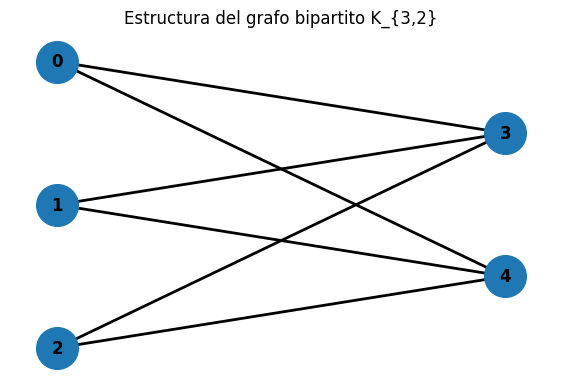

{0: (0.0, 2.0), 1: (0.0, 1.0), 2: (0.0, 0.0), 3: (2.0, 1.5), 4: (2.0, 0.5)}

In [5]:
# Posiciones fijas para que el bipartito K_{3,2} se vea con claridad.
pos_k32 = {0: (0.0, 2.0), 1: (0.0, 1.0), 2: (0.0, 0.0), 3: (2.0, 1.5), 4: (2.0, 0.5)}
draw_graph_structure(n_vertices, edges_k32, pos=pos_k32, title="Estructura del grafo bipartito K_{3,2}")

### Un corte máximo visto sobre el grafo

La cadena $00011$ coloca a los vértices $0,1,2$ en una parte y a los vértices $3,4$ en la otra. Como $K_{3,2}$ es bipartito, toda arista conecta un vértice de una parte con uno de la otra, de modo que las seis aristas quedan cortadas. La figura permite reconocer visualmente por qué $C(00011)=6$.

In [ ]:
draw_graph_partition("00011", edges_k32, pos=pos_k32, title="Corte óptimo para K_{3,2}: coloración 00011")

### Matriz de adyacencia

La matriz de adyacencia ofrece otra representación del mismo grafo. En Max-Cut resulta útil porque resume la conectividad y, en formulaciones más avanzadas, permite escribir la función objetivo como una suma sobre pares adyacentes. Para grafos pequeños, verla junto con el dibujo ayuda a conectar la descripción combinatoria con la estructura matricial.

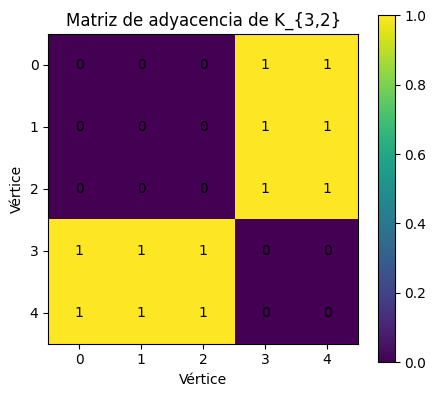

In [6]:
A_k32 = adjacency_matrix(n_vertices, edges_k32)
plt.figure(figsize=(5, 4.5))
plt.imshow(A_k32, interpolation="nearest")
plt.xticks(range(n_vertices))
plt.yticks(range(n_vertices))
plt.xlabel("Vértice")
plt.ylabel("Vértice")
plt.title("Matriz de adyacencia de K_{3,2}")
for i in range(n_vertices):
    for j in range(n_vertices):
        plt.text(j, i, str(A_k32[i, j]), ha="center", va="center")
plt.colorbar()
plt.show()

### Distribución de tamaños de corte

No todas las coloraciones producen el mismo valor. En esta instancia, la distribución completa de $C(x)$ muestra cuántas soluciones son pobres, intermedias u óptimas. Este tipo de visualización ayuda a entender qué tan selectivo debe ser el oráculo: si muy pocos estados son óptimos, Grover tiene una ventaja más visible al concentrar amplitud sobre ellos.

In [ ]:
plot_cut_values(n_vertices, edges_k32)
plot_cut_histogram(n_vertices, edges_k32)

### Ejemplo adicional: un ciclo impar

El ciclo $C_5$ ilustra una situación conceptualmente distinta. Si alternamos los colores tanto como sea posible, cuatro aristas quedan cortadas, pero una necesariamente no. La razón es combinatoria: en un ciclo impar no se puede mantener una alternancia perfecta al regresar al vértice inicial. Esta figura sirve para comparar un caso bipartito, donde sí puede cortarse toda arista, con un caso no bipartito, donde aparece una obstrucción estructural.

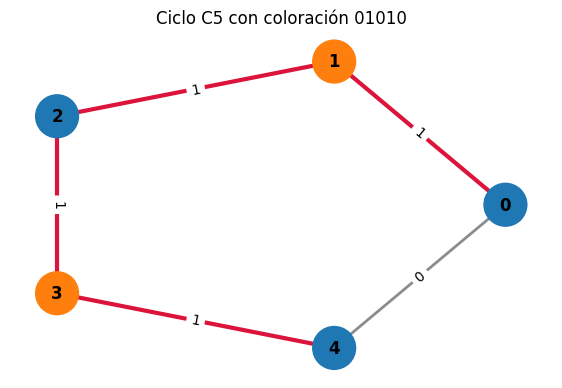

Valor del corte en C5 para 01010: 4
Valor máximo del corte en C5: 4


In [7]:
edges_c5: List[Edge] = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0)]
pos_c5 = nx.circular_layout(graph_from_edges(5, edges_c5))
draw_graph_partition("01010", edges_c5, pos=pos_c5, title="Ciclo C5 con coloración 01010")
print("Valor del corte en C5 para 01010:", cut_value("01010", edges_c5))
print("Valor máximo del corte en C5:", max_cuts(5, edges_c5)[0])

## 5. Indicadores de arista y XOR

Para una arista $\{i,j\}$, definimos el indicador

$$
e_{ij}=x_i\oplus x_j.
$$

Si $e_{ij}=1$, los extremos tienen colores distintos y la arista cruza el corte. Si $e_{ij}=0$, no cruza.

El tamaño del corte se escribe como

$$
C(x)=\sum_{\{i,j\}\in E} e_{ij}
=
\sum_{\{i,j\}\in E}(x_i\oplus x_j).
$$

Esta fórmula es la razón por la que CNOT y sumadores aparecen en el módulo: CNOT calcula XOR y los adders suman los indicadores.

In [8]:
def edge_indicator(bitstring: BitString, edge: Edge) -> int:
    """Devuelve 1 si una arista cruza el corte y 0 si no."""
    u, v = edge
    return int(bitstring[u] != bitstring[v])

x = "00111"
print("Coloración:", x)
for edge in edges_k32:
    print(edge, "->", edge_indicator(x, edge))
print("Suma de indicadores:", sum(edge_indicator(x, e) for e in edges_k32))

Coloración: 00111
(0, 3) -> 1
(0, 4) -> 1
(1, 3) -> 1
(1, 4) -> 1
(2, 3) -> 0
(2, 4) -> 0
Suma de indicadores: 4


## 6. Computación reversible

Los circuitos cuánticos cerrados son unitarios, y una operación unitaria es reversible. Por eso una función clásica que parece borrar información debe implementarse como una transformación extendida que conserve entradas y use registros auxiliares.

Para una función booleana $f$, la forma reversible típica es

$$
\left|x\right\rangle\left|y\right\rangle
\longmapsto
\left|x\right\rangle\left|y\oplus f(x)\right\rangle.
$$

En Max-Cut, los auxiliares almacenan indicadores de arista, bits de suma, acarreos y marcas. Después de aplicar la fase de marcado, esos auxiliares deben limpiarse para no contaminar la difusión de Grover.

## 7. CNOT como operador XOR

La compuerta CNOT implementa

$$
\operatorname{CNOT}\left|a\right\rangle\left|b\right\rangle
=
\left|a\right\rangle\left|b\oplus a\right\rangle.
$$

Si el objetivo inicia en $0$, una CNOT copia reversiblemente el valor del control hacia el objetivo. Si aplicamos dos CNOTs con controles $x_i$ y $x_j$ sobre el mismo auxiliar $t$, obtenemos

$$
t=0 \longmapsto x_i \longmapsto x_i\oplus x_j.
$$

## 8. Ejercicio guiado: detectar colores distintos

**Enunciado.** Los qubits $1$ y $2$ contienen los colores de dos vértices. El qubit $0$ inicia en $0$. Se desea que el qubit $0$ almacene $1$ si los colores son distintos y $0$ si son iguales.

**Desarrollo.** La condición deseada es $x_1\oplus x_2$. Primero se aplica CNOT desde $q_1$ hacia $q_0$; después se aplica CNOT desde $q_2$ hacia $q_0$:

$$
q_0:0\longmapsto x_1\longmapsto x_1\oplus x_2.
$$

**Interpretación.** El circuito no resuelve Max-Cut completo. Resuelve una subpregunta local: si una arista está cortada.

## 9. Half adder

El half adder suma dos bits $a$ y $b$ y produce:

$$
s=a\oplus b,
\qquad
c=ab.
$$

El bit $s$ es la suma módulo $2$ y $c$ es el acarreo. En circuitos reversibles, se usan auxiliares inicializados en cero para almacenar $s$ y $c$ sin modificar $a$ y $b$.

In [9]:
def half_adder_classical(a: int, b: int) -> Tuple[int, int]:
    """Devuelve (suma_mod_2, acarreo)."""
    s = a ^ b
    c = a & b
    return s, c

for a, b in product([0, 1], repeat=2):
    s, c = half_adder_classical(a, b)
    print(f"a={a}, b={b} -> suma={s}, acarreo={c}, binario={(c, s)}")

a=0, b=0 -> suma=0, acarreo=0, binario=(0, 0)
a=0, b=1 -> suma=1, acarreo=0, binario=(0, 1)
a=1, b=0 -> suma=1, acarreo=0, binario=(0, 1)
a=1, b=1 -> suma=0, acarreo=1, binario=(1, 0)


## 10. Full adder

El full adder incluye un acarreo de entrada $c_{in}$:

$$
s=a\oplus b\oplus c_{in},
$$

$$
c_{out}=ab\oplus c_{in}(a\oplus b).
$$

El segundo término expresa la regla de mayoría: hay acarreo de salida cuando al menos dos entradas valen $1$. En una implementación reversible se calcula un temporal $t=a\oplus b$, se usa para producir suma y acarreo, y luego se descomputa.

In [10]:
def full_adder_classical(a: int, b: int, cin: int) -> Tuple[int, int]:
    """Devuelve (suma_mod_2, acarreo_salida)."""
    s = a ^ b ^ cin
    cout = (a & b) ^ (cin & (a ^ b))
    return s, cout

for a, b, cin in product([0, 1], repeat=3):
    s, cout = full_adder_classical(a, b, cin)
    print(f"a={a}, b={b}, cin={cin} -> suma={s}, cout={cout}")

a=0, b=0, cin=0 -> suma=0, cout=0
a=0, b=0, cin=1 -> suma=1, cout=0
a=0, b=1, cin=0 -> suma=1, cout=0
a=0, b=1, cin=1 -> suma=0, cout=1
a=1, b=0, cin=0 -> suma=1, cout=0
a=1, b=0, cin=1 -> suma=0, cout=1
a=1, b=1, cin=0 -> suma=0, cout=1
a=1, b=1, cin=1 -> suma=1, cout=1


## 11. ¿Cuántos bits se necesitan para una suma?

Si se suman $m$ bits, el resultado máximo es $m$ y el mínimo es $0$. Se requieren suficientes bits para representar $m+1$ valores posibles:

$$
B(m)=\left\lceil \log_2(m+1)\right\rceil.
$$

Para sumar diez bits, el resultado está entre $0$ y $10$. Como $2^3=8<11$ y $2^4=16\ge 11$, se necesitan $4$ bits.

In [11]:
def bits_required_for_sum(m: int) -> int:
    """Número de bits necesarios para almacenar una suma entre 0 y m."""
    if m < 0:
        raise ValueError("m debe ser no negativo")
    return max(1, ceil(log2(m + 1)))

for m in [1, 2, 3, 4, 6, 10, 12, 20]:
    print(f"m={m:2d} -> bits necesarios = {bits_required_for_sum(m)}")

m= 1 -> bits necesarios = 1
m= 2 -> bits necesarios = 2
m= 3 -> bits necesarios = 2
m= 4 -> bits necesarios = 3
m= 6 -> bits necesarios = 3
m=10 -> bits necesarios = 4
m=12 -> bits necesarios = 4
m=20 -> bits necesarios = 5


## 12. Comparadores binarios

Un comparador decide si un registro binario coincide con un patrón o supera un umbral. Para detectar igualdad con un patrón, se usan controles positivos para bits que deben ser $1$ y controles negativos para bits que deben ser $0$.

Los controles negativos se implementan con la técnica:

1. Aplicar $X$ sobre los qubits que deberían ser $0$.
2. Aplicar una compuerta multi-controlada que se active cuando todos los controles son $1$.
3. Deshacer las compuertas $X$.

Así se marca un patrón sin modificar permanentemente el registro de entrada.

## 13. Ejercicio guiado: detectar $1011_2$

**Enunciado.** El registro $q_0,q_1,q_2,q_3$ representa $b_0,b_1,b_2,b_3$. Se desea activar $q_4$ si el número almacenado es $1011_2$.

**Desarrollo.** El patrón $1011_2$ significa:

$$
b_3=1,
\qquad
b_2=0,
\qquad
b_1=1,
\qquad
b_0=1.
$$

Como $b_2$ está en $q_2$, aplicamos $X(q_2)$ antes de la compuerta multi-controlada. Después aplicamos $X(q_4)$ controlada por $q_0,q_1,q_2,q_3$ y finalmente deshacemos $X(q_2)$.

**Interpretación.** El comparador transforma una condición numérica en un bit de marca reversible.

In [12]:
def pattern_match(bitstring: BitString, pattern: BitString) -> bool:
    """Comprueba igualdad entre dos cadenas binarias."""
    if len(bitstring) != len(pattern):
        raise ValueError("Las longitudes no coinciden")
    return bitstring == pattern

for value in ["1011", "1111", "0011", "1010"]:
    print(value, "coincide con 1011?", pattern_match(value, "1011"))

1011 coincide con 1011? True
1111 coincide con 1011? False
0011 coincide con 1011? False
1010 coincide con 1011? False


## 14. Integración: de Max-Cut a oráculo para Grover

La arquitectura completa es:

1. Preparar una superposición uniforme de coloraciones.
2. Calcular indicadores de arista $e_{ij}=x_i\oplus x_j$.
3. Sumar los indicadores para obtener $C(x)$.
4. Comparar $C(x)$ con un criterio, por ejemplo $C(x)=T$.
5. Convertir la marca en una fase.
6. Deshacer comparación, suma e indicadores.
7. Aplicar difusión de Grover.

El punto más importante es que Grover no calcula Max-Cut por sí solo. Grover amplifica lo que el oráculo es capaz de reconocer.

## 15. Qiskit: instalación condicional

La siguiente celda intenta importar Qiskit. Si no está disponible, intenta instalar `qiskit` y `qiskit-aer`. En Google Colab esto permite ejecutar el notebook sin edición manual.

In [15]:
import importlib
import subprocess
import sys


def ensure_package(import_name: str, pip_name: Optional[str] = None) -> None:
    """Importa un paquete; si no existe, intenta instalarlo con pip."""
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        print(f"Instalando {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Estas instalaciones solo se ejecutan si faltan los paquetes.
ensure_package("qiskit", "qiskit")
ensure_package("qiskit_aer", "qiskit-aer")

Instalando qiskit-aer ...


## 16. Qiskit: bloques reversibles básicos

La siguiente celda define tres herramientas:

- `edge_indicator_qiskit`: calcula el XOR de una arista en un auxiliar.
- `half_adder_qiskit`: construye un half adder reversible.
- `mark_state_phase_qiskit`: aplica una fase negativa a un estado base específico.

La última función se usa para una demostración compacta de Grover. En un oráculo aritmético completo, el marcado de fase se obtiene a partir del conteo reversible y del comparador.

In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


def edge_indicator_qiskit(qc: QuantumCircuit, u: int, v: int, t: int) -> None:
    """Calcula x_u xor x_v en el auxiliar t."""
    qc.cx(u, t)
    qc.cx(v, t)


def half_adder_qiskit(qc: QuantumCircuit, a: int, b: int, s: int, c: int) -> None:
    """Half adder reversible: s = a xor b, c = a and b."""
    qc.cx(a, s)
    qc.cx(b, s)
    qc.ccx(a, b, c)


def mark_state_phase_qiskit(qc: QuantumCircuit, qubits: Sequence[int], bitstring: BitString) -> None:
    """Aplica fase -1 al estado base indicado por bitstring.

    Convención: bitstring[i] corresponde al qubit qubits[i].
    """
    if len(qubits) != len(bitstring):
        raise ValueError("El número de qubits y bits no coincide")
    for q, b in zip(qubits, bitstring):
        if b == '0':
            qc.x(q)
    qc.h(qubits[-1])
    qc.mcx(list(qubits[:-1]), qubits[-1])
    qc.h(qubits[-1])
    for q, b in reversed(list(zip(qubits, bitstring))):
        if b == '0':
            qc.x(q)

## 17. Qiskit: difusión de Grover

La difusión alrededor del estado uniforme invierte amplitudes respecto a la media. En código se implementa como Hadamards, compuertas $X$, una fase controlada sobre el estado $\left|0\cdots 0\right\rangle$ y luego la operación inversa.

In [17]:
def diffusion_qiskit(qc: QuantumCircuit, qubits: Sequence[int]) -> None:
    """Operador de difusión de Grover sobre los qubits indicados."""
    qc.h(qubits)
    qc.x(qubits)
    qc.h(qubits[-1])
    qc.mcx(list(qubits[:-1]), qubits[-1])
    qc.h(qubits[-1])
    qc.x(qubits)
    qc.h(qubits)


def grover_for_marked_states_qiskit(n: int, marked_states: Sequence[BitString], iterations: int) -> QuantumCircuit:
    """Circuito de Grover que marca directamente una lista de estados.

    Esta versión es demostrativa. Para el oráculo algorítmico completo, la lista de estados se sustituye
    por compute -> compare -> phase -> uncompute.
    """
    qc = QuantumCircuit(n, n)
    qubits = list(range(n))
    qc.h(qubits)
    for _ in range(iterations):
        for state in marked_states:
            mark_state_phase_qiskit(qc, qubits, state)
        diffusion_qiskit(qc, qubits)
    for i in range(n):
        # Medición en orden conceptual: qubit i se imprime en posición i de la cadena final.
        qc.measure(i, n - 1 - i)
    return qc


def run_qiskit_counts(qc: QuantumCircuit, shots: int = 2048) -> Dict[str, int]:
    simulator = AerSimulator()
    tqc = transpile(qc, simulator)
    result = simulator.run(tqc, shots=shots).result()
    return dict(result.get_counts())

## 18. Qiskit: demostración con el grafo $K_{3,2}$

Primero calculamos clásicamente el valor óptimo para verificar la instancia pequeña. Después construimos un circuito de Grover que marca las coloraciones óptimas. Esta versión de marcado directo es útil para observar la amplificación; el oráculo reversible completo se obtiene reemplazando la lista de óptimos por el cálculo de indicadores, suma y comparación.

In [18]:
# Max-Cut del grafo K_{3,2}
best_value, marked_states = max_cuts(n_vertices, edges_k32)
iterations = round((pi / 4) * sqrt((2 ** n_vertices) / len(marked_states)))
print("Valor máximo:", best_value)
print("Estados marcados:", marked_states)
print("Iteraciones aproximadas:", iterations)

qc_grover = grover_for_marked_states_qiskit(n_vertices, marked_states, iterations)
counts = run_qiskit_counts(qc_grover, shots=2048)
print(counts)

Valor máximo: 6
Estados marcados: ['00011', '11100']
Iteraciones aproximadas: 3
{'01101': 1, '00010': 1, '01111': 3, '01110': 3, '00100': 3, '11110': 1, '00000': 5, '11001': 2, '11000': 3, '11111': 1, '11011': 2, '10000': 1, '00111': 2, '00011': 982, '11101': 6, '01011': 2, '10011': 5, '01001': 1, '11010': 1, '10001': 1, '00001': 3, '10010': 1, '11100': 999, '10101': 1, '10111': 2, '01010': 4, '00110': 1, '01000': 5, '01100': 6}


### Probabilidad teórica de éxito frente al número de iteraciones

La representación gráfica del algoritmo de Grover también es instructiva. Si $N$ es el número total de estados y $M$ el número de estados marcados, la probabilidad ideal de medir una solución tras $k$ iteraciones es

$$
P_k = \sin^2ig((2k+1)	hetaig), \qquad \sin^2	heta = 
rac{M}{N}.
$$

La curva siguiente permite ver por qué no conviene iterar indefinidamente: la amplitud crece, alcanza un máximo y luego vuelve a disminuir. En la práctica, esta gráfica justifica la elección del número de iteraciones usado en la simulación.

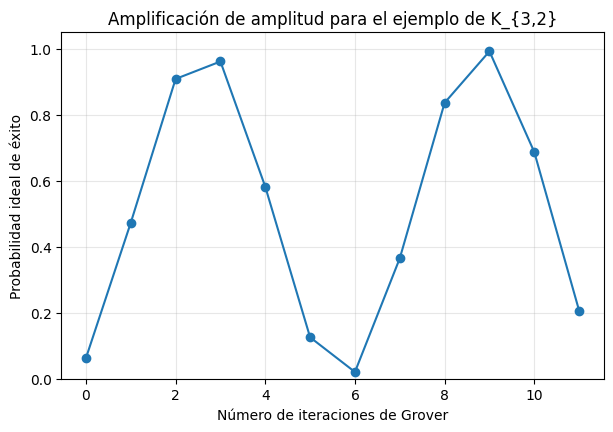

Máximo dentro del rango graficado en k=9 con P=0.9922


In [19]:
def grover_success_probability(N: int, M: int, k: int) -> float:
    """Probabilidad ideal de éxito de Grover tras k iteraciones."""
    theta = np.arcsin(np.sqrt(M / N))
    return float(np.sin((2 * k + 1) * theta) ** 2)

N = 2 ** n_vertices
M = len(marked_states)
ks = list(range(0, 12))
probs = [grover_success_probability(N, M, k) for k in ks]

plt.figure(figsize=(7, 4.5))
plt.plot(ks, probs, marker="o")
plt.xlabel("Número de iteraciones de Grover")
plt.ylabel("Probabilidad ideal de éxito")
plt.title("Amplificación de amplitud para el ejemplo de K_{3,2}")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

best_k = ks[int(np.argmax(probs))]
print(f"Máximo dentro del rango graficado en k={best_k} con P={max(probs):.4f}")

### Interpretación de los conteos

Si el circuito ideal se comporta como se espera, las cadenas óptimas aparecen con frecuencia dominante. Para el grafo $K_{3,2}$, las coloraciones $00011$ y $11100$ corresponden al corte que separa las dos partes del grafo. Sus complementos representan el mismo corte combinatorio, aunque son estados base diferentes.

## 19. Cirq: instalación condicional

La siguiente celda intenta importar Cirq. Si no está disponible, intenta instalarlo. En Google Colab puede tardar algunos segundos.

In [ ]:
ensure_package("cirq", "cirq")

## 20. Cirq: indicadores y marcado

Cirq permite expresar controles múltiples con `controlled_by`. La estructura conceptual es la misma que en Qiskit: calcular indicadores, marcar, y descomputar.

In [ ]:
import cirq


def edge_indicator_cirq(circuit: cirq.Circuit, qubits: Sequence[cirq.Qid], u: int, v: int, t: int) -> None:
    """Calcula x_u xor x_v en el auxiliar t usando dos CNOTs."""
    circuit.append(cirq.CNOT(qubits[u], qubits[t]))
    circuit.append(cirq.CNOT(qubits[v], qubits[t]))


def phase_mark_state_cirq(circuit: cirq.Circuit, qubits: Sequence[cirq.Qid], bitstring: BitString) -> None:
    """Aplica una fase -1 al estado base indicado por bitstring."""
    if len(qubits) != len(bitstring):
        raise ValueError("El número de qubits y bits no coincide")
    for q, b in zip(qubits, bitstring):
        if b == '0':
            circuit.append(cirq.X(q))
    circuit.append(cirq.Z(qubits[-1]).controlled_by(*qubits[:-1]))
    for q, b in reversed(list(zip(qubits, bitstring))):
        if b == '0':
            circuit.append(cirq.X(q))


def diffusion_cirq(circuit: cirq.Circuit, qubits: Sequence[cirq.Qid]) -> None:
    """Operador de difusión de Grover en Cirq."""
    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(cirq.Z(qubits[-1]).controlled_by(*qubits[:-1]))
    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(cirq.H.on_each(*qubits))

In [ ]:
def grover_for_marked_states_cirq(n: int, marked_states: Sequence[BitString], iterations: int) -> cirq.Circuit:
    """Circuito de Grover en Cirq para una lista demostrativa de estados marcados."""
    qubits = cirq.LineQubit.range(n)
    circuit = cirq.Circuit()
    circuit.append(cirq.H.on_each(*qubits))
    for _ in range(iterations):
        for state in marked_states:
            phase_mark_state_cirq(circuit, qubits, state)
        diffusion_cirq(circuit, qubits)
    circuit.append(cirq.measure(*qubits, key='z'))
    return circuit

cirq_circuit = grover_for_marked_states_cirq(n_vertices, marked_states, iterations)
print(cirq_circuit)

sim = cirq.Simulator()
result = sim.run(cirq_circuit, repetitions=1024)
print(result.histogram(key='z'))

## 21. Ejercicios guiados

### Ejercicio 1: estado de coloración

Tres vértices se codifican con tres qubits. Si $x_0=1$, $x_1=0$ y $x_2=0$, entonces la cadena es $100$ y el estado base es

$$
\left|100\right\rangle.
$$

### Ejercicio 2: indicador de arista

Si una arista conecta colores $x_i=1$ y $x_j=0$, entonces

$$
e_{ij}=1\oplus 0=1.
$$

La arista cruza el corte.

### Ejercicio 3: bits para sumar diez indicadores

La suma está entre $0$ y $10$, por lo que se necesitan $4$ bits.

## 22. Ejercicios guiados con desarrollo paso a paso

### Ejercicio 4: comparador para $1011_2$

El patrón $1011_2$ tiene un cero en la posición $b_2$. Si $b_2$ está en $q_2$, se aplica $X(q_2)$ antes de la multi-controlada y se deshace después. La marca queda condicionada a que todos los bits transformados sean $1$.

### Ejercicio 5: suma módulo 2 en un objetivo

Para almacenar $a\oplus b$ en un objetivo $t$ inicializado en $0$, se aplican dos CNOTs:

$$
t:0\longmapsto a\longmapsto a\oplus b.
$$

Si el objetivo inicia en $c$, el resultado es $c\oplus a\oplus b$.

## 23. Ejercicios propuestos

1. Para un ciclo de cinco vértices, propón una coloración y calcula cuántas aristas cruzan. Explica por qué no pueden cruzar las cinco aristas simultáneamente.
2. Determina cuántos bits se necesitan para almacenar la suma de $12$ indicadores y de $20$ indicadores.
3. Diseña el esquema reversible para marcar un registro de conteo igual a $0110_2$.
4. Para el grafo $K_{3,2}$, verifica que las coloraciones $00011$ y $11100$ tienen el mismo corte.
5. Explica por qué un oráculo que deja auxiliares sin limpiar puede afectar la difusión de Grover.

## 24. Resumen final

Max-Cut aporta el problema combinatorio: elegir una partición que maximice aristas cruzadas. La codificación binaria convierte cada partición en una cadena de bits y cada arista cortada en una XOR.

Los adders aportan el mecanismo reversible que permite sumar indicadores de arista. Half adders, full adders y ripple carry adders hacen posible construir registros de conteo sin destruir información.

Los comparadores convierten el conteo en una marca lógica. Después, esa marca puede transformarse en fase y usarse dentro de Grover.

La integración completa es:

$$
\text{coloración}
\longrightarrow
\text{indicadores}
\longrightarrow
\text{conteo reversible}
\longrightarrow
\text{comparador}
\longrightarrow
\text{fase}
\longrightarrow
\text{Grover}.
$$

La conclusión conceptual es que Grover no reemplaza la construcción del oráculo. La parte central del módulo es aprender a convertir una función objetivo clásica en un predicado reversible compatible con interferencia cuántica.